# <center> Big Data for Finance project: Health Insurance Cross-Selling

> - __Ahmed Abdelazeem__ (m20210433)
> - __Omar Jarir__ (m20201378)  
> - __Chung-Ting Huang__ (m20210437) 
> - __Pedro Moura Gomes__ (m20200322)

***

The goal of this project is to build following four Classification models to accurately classify "Response" variable:

- Logistic Regression.
- Decision Tree.
- Random Forest.
- Gradient Boosted Tree.
- Artificial Neural Network.

- The used data set is from https://www.kaggle.com/code/lchen36/plotly-random-f-dtree-logistic-knn-auc-83/data

***

# Requirement
This notebook needs databricks runtime 10.4 LTS (includes Apache Spark 3.2.1, Scala 2.12)

To use Kafka, we need to install a library. Under clusters -> libraries -> maven -> search packages, install spark-kafka-writer. The coordinates is com.github.benfradet:spark-kafka-writer_2.11:0.4.0

In [0]:
import json
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import auc
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_curve # confusion_matrix

In [0]:
from pyspark.sql.functions import isnan, when, count, col
from pyspark.ml.classification import (LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier, 
                                       MultilayerPerceptronClassifier, DecisionTreeClassifier) 
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder, StandardScaler, MinMaxScaler
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator, ClusteringEvaluator
from pyspark.mllib.classification import StreamingLogisticRegressionWithSGD
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.ml.stat import Correlation
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans 
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType
from pyspark.mllib.evaluation import BinaryClassificationMetrics
from pyspark.mllib.linalg import Vectors
from pyspark.mllib.regression import LabeledPoint
from pyspark.ml.stat import Correlation
from pyspark.streaming import StreamingContext

In [0]:
import warnings
warnings.filterwarnings("ignore")

In [0]:
import time
t1 = time.perf_counter()

### Constants

In [0]:
SEED = 2022
DB_HOST = 'ec2-63-32-248-14.eu-west-1.compute.amazonaws.com'
DB_NAME = 'd7i77o2nche0a9'
DB_USER = 'delowjbrpkvrms'
DB_PORT = 5432
DB_PASSWORD = '75f8be77294f6b0b23dd8cc9d1518025ddc26c5ab91e4c2ab4e07ef13b813ba8'
KAFKA_HOST_PORT = 'humble-cat-14436-eu1-kafka.upstash.io:9092'
KAFKA_USERNAME = 'aHVtYmxlLWNhdC0xNDQzNiQPm_F1rwy3b1Kj__OZ6lQ0g4CxxtQygbcrBh6XEOc'
KAFKA_PASSWORD = 'weDC7M2nN0Nu_NavHHkhkLk3HFJWKwCxkBghYcdBsWkk8D-NkXQAQM4g10m8749kfDTHFw=='
KAFKA_TOPIC = 'insurance_customer'

### Helper functions:

In [0]:
def corr(ds):
    corr = ds.corr()
    # Generate a lower triangle matrix, where the lower and diagnoal are true, but upper is false
    mask = np.zeros_like(corr, dtype=np.bool)
    mask[np.triu_indices_from(mask)]= True

    _, ax = plt.subplots(figsize=(12,8))
    sns.heatmap(corr,
        mask = mask,
        square = True,
        linewidths = .5,
        cmap = 'viridis',
        vmin = -1,
        vmax = 1,
        annot = True,
        annot_kws = {'size': 10})

    # Add the column names to labels
    ax.set_yticklabels(corr.columns, rotation = 0)
    ax.set_xticklabels(corr.columns, rotation = 60)
    sns.set_style({'xtick.bottom': True}, {'ytick.left': True})

In [0]:
def Pipeline_model(stages, cv, train_data, test_data, eps=0.01):
    """
    
    """
    p = Pipeline(stages=stages + [cv]) 
    pipeline_model = p.fit(train_data)
    predDF = pipeline_model.transform(test_data)

    return pipeline_model, predDF

In [0]:
# User defined function.
firstelement = udf(lambda v: float(v[1]), FloatType())

def prediction_vectors(predDF):
    
    y_test = predDF.select(["label"]).collect()
    y_pred_test = predDF.select(["prediction"]).collect()
    y_pred_test_proba = predDF.select(firstelement('probability')).collect()
    
    print(classification_report(y_test, y_pred_test))
    y_test = np.array([y_test[idx][0] for idx in range(len(y_test))])
    y_pred_test = np.array([y_pred_test[idx][0] for idx in range(len(y_pred_test))])
    y_pred_test_proba = np.array([y_pred_test_proba[idx][0] for idx in range(len(y_pred_test_proba))])
    
    return y_test, y_pred_test, y_pred_test_proba

In [0]:
def Metrics(predDF, eps= 0.01):
    '''
    '''
    
    # Create and print a confusion matrix:
    print("The confusion matrix of our model is as follow:\n")
    cm = predDF.groupBy("label", 'prediction').count().toPandas() 

    cm = pd.pivot_table(cm, values='count', index=['label'],
                    columns=['prediction'], aggfunc=np.sum, fill_value=0)
    print(cm)
    
    # Calculate the elements of the confusion matrix
    TN = predDF.filter('prediction = 0 AND label = prediction').count()
    TP = predDF.filter('prediction = 1 AND label = prediction').count()
    FN = predDF.filter('prediction = 0 AND label != prediction').count()
    FP = predDF.filter('prediction = 1 AND label != prediction').count()

    # Accuracy measures the proportion of correct predictions
    accuracy = (TN+TP)/(TN+TP+FN+FP+eps)
    precision = TP/(TP+FP+eps)
    recall = TP/(TP+FN+eps)
    F1 = 2*precision*recall/(precision+recall+eps)
    print(f"The accuracy value is equal to {accuracy:.2f}")
    print(f"The precision value is equal to {precision:.2f}")
    print(f"The recall value is equal to {recall:.2f}")
    print(f"The F1-score value is equal to {F1:.2f}")
        
    return cm
    

In [0]:
def auc_plot(y_test, y_pred_test_proba):
    '''
    Plot the ROC curve.
    '''
    fpr, tpr, _ = roc_curve(y_test, y_pred_test_proba)
    auc_keras = auc(fpr, tpr)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.plot(fpr, tpr, label='AUC (area = {:.3f})'.format(auc_keras), color="g")
    plt.grid(axis='both', linestyle='--', color="#add8e6")
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title('ROC curve')
    plt.legend(loc='best')
    plt.show();

In [0]:
def remove_outliers(x_train, x_test, y_train, y_test, cols, estimators=100):
    ''' 
    Uses an isolation forest in order to detect and remove outliers.
    '''
    isolation_forest = IsolationForest(n_estimators=estimators, random_state=SEED)
    
    #identify outliers:
    y_train_pred = isolation_forest.fit_predict(x_train[cols])
    y_test_pred = isolation_forest.predict(x_test[cols])

    #Remove outliers where 1 represent inliers and -1 represent outliers:
    x_train = x_train[np.where(y_train_pred == 1, True, False)]
    x_test = x_test[np.where(y_test_pred == 1, True, False)]

    y_train = y_train[np.where(y_train_pred == 1, True, False)]
    y_test = y_test[np.where(y_test_pred == 1, True, False)] 
    
    return x_train, x_test, y_train, y_test

***

### Loading the data:
We upload the training data to a Postgres database hosted on Heroku

In [0]:
df = spark.read.format("jdbc"). \
options(
         url=f'jdbc:postgresql://{DB_HOST}:{DB_PORT}/{DB_NAME}', # jdbc:postgresql://<host>:<port>/<database>
         dbtable='insurance_train',
         user=DB_USER,
         password=DB_PASSWORD,
         driver='org.postgresql.Driver').\
load()

In [0]:
data = df.withColumnRenamed("Response", "label")

In [0]:
data.printSchema()

root
 |-- id: integer (nullable = true)
 |-- original_id: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: short (nullable = true)
 |-- driving_license: short (nullable = true)
 |-- region_code: float (nullable = true)
 |-- previously_insured: short (nullable = true)
 |-- vehicle_age: string (nullable = true)
 |-- vehicle_damage: string (nullable = true)
 |-- annual_premium: float (nullable = true)
 |-- policy_sales_channel: float (nullable = true)
 |-- vintage: short (nullable = true)
 |-- label: short (nullable = true)



In [0]:
data = data.drop("original_id")

In [0]:
data.show(5, truncate=False, vertical=True)

-RECORD 0------------------------
 id                   | 0        
 gender               | Male     
 age                  | 52       
 driving_license      | 1        
 region_code          | 30.0     
 previously_insured   | 0        
 vehicle_age          | 1-2 Year 
 vehicle_damage       | Yes      
 annual_premium       | 2630.0   
 policy_sales_channel | 156.0    
 vintage              | 180      
 label                | 0        
-RECORD 1------------------------
 id                   | 1        
 gender               | Male     
 age                  | 40       
 driving_license      | 1        
 region_code          | 28.0     
 previously_insured   | 0        
 vehicle_age          | 1-2 Year 
 vehicle_damage       | Yes      
 annual_premium       | 29651.0  
 policy_sales_channel | 124.0    
 vintage              | 47       
 label                | 0        
-RECORD 2------------------------
 id                   | 2        
 gender               | Male     
 age          

In [0]:
data.count()

Out[17]: 66704

In [0]:
# Checking if the data frame contains duplicates
data.distinct().count()

Out[18]: 66704

In [0]:
data.select([count(when(isnan(c), c)).alias(c) for c in data.columns]).toPandas()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,label
0,0,0,0,0,0,0,0,0,0,0,0,0


In [0]:
# Dropping the "id" columns.
data = data.drop(col("id"))

***

## Data exploration:

In [0]:
# Creating a table to perform some sql queries.
data.createOrReplaceTempView("dataTable")

In [0]:
data.printSchema()

root
 |-- gender: string (nullable = true)
 |-- age: short (nullable = true)
 |-- driving_license: short (nullable = true)
 |-- region_code: float (nullable = true)
 |-- previously_insured: short (nullable = true)
 |-- vehicle_age: string (nullable = true)
 |-- vehicle_damage: string (nullable = true)
 |-- annual_premium: float (nullable = true)
 |-- policy_sales_channel: float (nullable = true)
 |-- vintage: short (nullable = true)
 |-- label: short (nullable = true)



### 'label'

In [0]:
# The data set is balanced.
spark.sql("""SELECT label, count(*) as _count
          From dataTable
          Group by label
          ORDER BY _count""").show()

+-----+------+
|label|_count|
+-----+------+
|    1| 33352|
|    0| 33352|
+-----+------+



### 'Gender'

In [0]:
# There are more males than females
spark.sql("""SELECT gender, count(gender) as gender_count
          From dataTable
          Group by gender
          ORDER BY gender_count""").show()

+------+------------+
|gender|gender_count|
+------+------------+
|Female|       26229|
|  Male|       40475|
+------+------------+



In [0]:
spark.sql("""SELECT DISTINCT count(gender) as count_gender, gender, label
          From dataTable
          Group by gender, label
          ORDER BY count_gender""").show()

+------------+------+-----+
|count_gender|gender|label|
+------------+------+-----+
|       10537|Female|    1|
|       15692|Female|    0|
|       17660|  Male|    0|
|       22815|  Male|    1|
+------------+------+-----+



### 'Age'

In [0]:
# We can notice the average age with label 0 is lower than with label 1
spark.sql("""SELECT label, mean(age) as mean_age
          From dataTable
          Group by label
          ORDER BY mean_age""").show()

+-----+------------------+
|label|          mean_age|
+-----+------------------+
|    0|38.051061405612856|
|    1|  42.8541916526745|
+-----+------------------+



In [0]:
# The minimum age on the data set is 20, while the maximum age is 85.
spark.sql("""SELECT min(age) as min_age, max(age) as max_age
            From dataTable""").show()

+-------+-------+
|min_age|max_age|
+-------+-------+
|     20|     85|
+-------+-------+



### Driving_Licence

In [0]:
# Most observations have a driving licence.
spark.sql("""SELECT DISTINCT count(driving_license) as count_driving_license, driving_license
          From dataTable
          Group by driving_license
          ORDER BY count_driving_license""").show()

+---------------------+---------------+
|count_driving_license|driving_license|
+---------------------+---------------+
|                   61|              0|
|                66643|              1|
+---------------------+---------------+



In [0]:
# Almost everyone has a driver license. It does not provide much predictive power, so we drop it
data = data.drop(col("driving_license"))

### 'Region_Code'

In [0]:
# There are 53 unique region codes, we decide to drop this variable because it will likely lead to overfiting 
print(spark.sql("SELECT count(DISTINCT(region_code)) FROM dataTable").show())
spark.sql("""SELECT DISTINCT count(region_code) as count_region_code, Region_Code
          From dataTable
          Group by Region_Code
          ORDER BY count_region_code""").show()

+---------------------------+
|count(DISTINCT region_code)|
+---------------------------+
|                         53|
+---------------------------+

None
+-----------------+-----------+
|count_region_code|Region_Code|
+-----------------+-----------+
|               39|       51.0|
|               43|       52.0|
|               45|       42.0|
|               99|       44.0|
|              136|        1.0|
|              153|       22.0|
|              177|       40.0|
|              188|        5.0|
|              199|       34.0|
|              213|       49.0|
|              246|       16.0|
|              249|       19.0|
|              263|        4.0|
|              264|       17.0|
|              267|       25.0|
|              278|       23.0|
|              278|        0.0|
|              313|       20.0|
|              318|       24.0|
|              318|       26.0|
+-----------------+-----------+
only showing top 20 rows



In [0]:
data = data.drop(col("region_code"))

### 'Previously_Insured'

In [0]:
# Only 20 previously insured customers are intersted in buying a vehicle insurance.
spark.sql("""SELECT DISTINCT count(previously_insured) as count_previously_insured, previously_insured, label
          From dataTable
          Group by previously_insured, label
          ORDER BY count_previously_insured""").show()

+------------------------+------------------+-----+
|count_previously_insured|previously_insured|label|
+------------------------+------------------+-----+
|                      20|                 1|    1|
|                   15874|                 0|    0|
|                   17478|                 1|    0|
|                   33332|                 0|    1|
+------------------------+------------------+-----+



### 'Vehicle_Age'

In [0]:
# Most vehicles ages are between 1 and 2 years
spark.sql("""SELECT DISTINCT count(vehicle_age) as count_vehicle_age, vehicle_age
          From dataTable
          Group by vehicle_age
          ORDER BY count_vehicle_age""").show()

+-----------------+-----------+
|count_vehicle_age|vehicle_age|
+-----------------+-----------+
|             2522|  > 2 Years|
|            18093|   < 1 Year|
|            46089|   1-2 Year|
+-----------------+-----------+



### 'Vehicle_Damage'

In [0]:
# We can see that almost half of the vehicles have damage.
spark.sql("""SELECT Vehicle_damage, count(vehicle_damage) as count_vehicle_damage
          From dataTable
          Group by Vehicle_damage
          ORDER BY count_vehicle_damage""").show()

+--------------+--------------------+
|Vehicle_damage|count_vehicle_damage|
+--------------+--------------------+
|            No|               18870|
|           Yes|               47834|
+--------------+--------------------+



### 'Annual_Premium'

In [0]:
# The 'annual_premium' variable has a wide range from 2630 to 495106
spark.sql("""SELECT min(annual_premium) as min_premium, max(annual_premium) as max_premium
            FROM dataTable""").show()

+-----------+-----------+
|min_premium|max_premium|
+-----------+-----------+
|     2630.0|   495106.0|
+-----------+-----------+



### 'Policy_Sales_Channel'

In [0]:
spark.sql("""SELECT DISTINCT count(policy_sales_channel) as count_policy_sales_channel, policy_sales_channel
          From dataTable
          Group by policy_sales_channel
          ORDER BY count_policy_sales_channel""").show()

+--------------------------+--------------------+
|count_policy_sales_channel|policy_sales_channel|
+--------------------------+--------------------+
|                         1|           34.430244|
|                         1|          104.001656|
|                         1|           132.23026|
|                         1|           122.48544|
|                         1|           138.75737|
|                         1|           107.15124|
|                         1|           85.853516|
|                         1|           142.04536|
|                         1|          106.974205|
|                         1|            33.68701|
|                         1|            35.24503|
|                         1|           140.72725|
|                         1|            34.14439|
|                         1|           142.79454|
|                         1|           120.73935|
|                         1|           72.493385|
|                         1|           130.74207|


### 'Vintage'

In [0]:
spark.sql("""SELECT DISTINCT count(vintage) as count_vintage, vintage
          From dataTable
          Group by vintage
          ORDER BY count_vintage""").show()

+-------------+-------+
|count_vintage|vintage|
+-------------+-------+
|          109|    294|
|          117|    295|
|          124|     12|
|          128|    299|
|          128|     11|
|          137|    296|
|          139|     10|
|          139|    298|
|          139|     13|
|          143|    297|
|          144|    290|
|          146|     14|
|          147|    293|
|          148|    291|
|          149|     20|
|          152|    284|
|          152|     18|
|          154|    285|
|          155|     19|
|          155|    289|
+-------------+-------+
only showing top 20 rows



***

In [0]:
# Getting the average of all the numerical features.
data.select(["label", "Age", "Annual_Premium", "Policy_Sales_Channel", "Vintage"]).groupBy('label').avg().toPandas().drop(columns='avg(label)')

,label,avg(Age),avg(Annual_Premium),avg(Policy_Sales_Channel),avg(Vintage)
0,1,42.854192,31361.883174,92.669101,152.720227
1,0,38.051061,30486.014962,115.041227,154.893979


In [0]:
# # Getting the minimum of all the numerical features.
data.select(["label", "Age", "Annual_Premium", "Policy_Sales_Channel", "Vintage"]).groupBy('label').min().toPandas().drop(columns='min(label)')

,label,min(Age),min(Annual_Premium),min(Policy_Sales_Channel),min(Vintage)
0,1,20,2630.0,1.0,10
1,0,20,2630.0,1.0,10


In [0]:
# Getting the maximum of all the numerical features.
data.select(["label", "Age", "Annual_Premium", "Policy_Sales_Channel", "Vintage"]).groupBy('label').max().toPandas().drop(columns='max(label)')

,label,max(Age),max(Annual_Premium),max(Policy_Sales_Channel),max(Vintage)
0,1,80,489663.0,163.0,299
1,0,85,495106.0,163.0,299


### Correlations

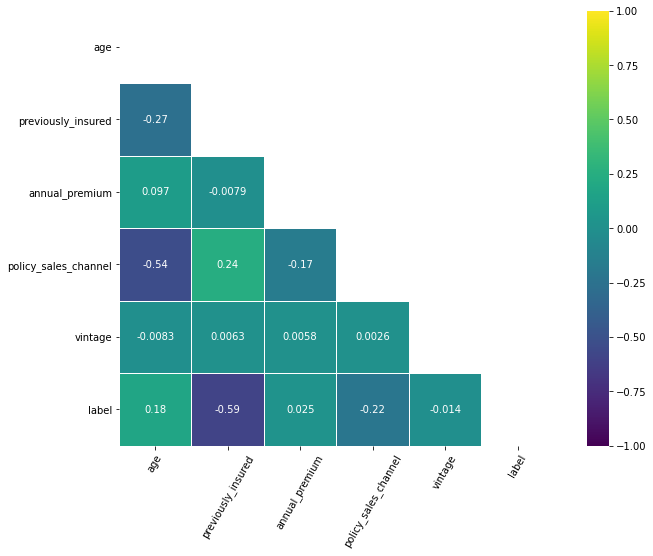

In [0]:
# When can't notice strong correlation between the features.
corr(data.toPandas())

In [0]:
# Ordinal encoding the variable 'vehicle_age'
data = data.withColumn("vehicle_age", when(data.vehicle_age == '< 1 Year', 0).when(data.vehicle_age == '1-2 Year', 1).when(data.vehicle_age == '> 2 Years', 2))

### Spliting the data set into a train and a test sets.

In [0]:
# Training and test dataset have about the same percentage of class 1
train_data, test_data = data.randomSplit([0.7, 0.3], seed=SEED)
train_data.groupBy('label').count().show()
test_data.groupBy('label').count().show()

+-----+-----+
|label|count|
+-----+-----+
|    1|23381|
|    0|23313|
+-----+-----+

+-----+-----+
|label|count|
+-----+-----+
|    1| 9971|
|    0|10039|
+-----+-----+



In [0]:
# Converting the data sets into pandas dataframes in order to deal with outliers.

x_train = train_data.toPandas()
x_test = test_data.toPandas()

y_train = x_train["label"]
x_train = x_train.drop(columns=["label"])

y_test = x_test["label"]
x_test = x_test.drop(columns=["label"])

### Removing outliers outliers

In [0]:
categoricalCols = ["gender", "previously_insured", "vehicle_damage"] 
numericCols = ["vehicle_age", "age", "annual_premium", "policy_sales_channel", "vintage"]
x_train, x_test, y_train, y_test = remove_outliers(x_train, x_test, y_train, y_test, numericCols, estimators=100)

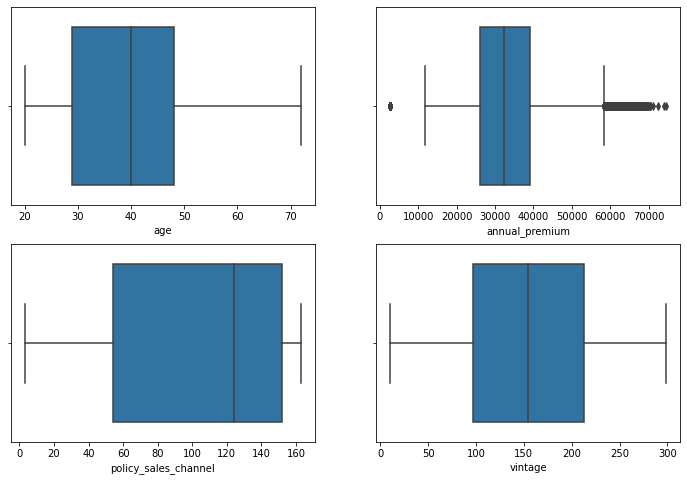

In [0]:
# I should correct this one check the new numerical features we have.
_, axs = plt.subplots(2, 2, figsize=(12,8))
for i, c in enumerate(filter(lambda x: x!='vehicle_age', numericCols)):
    ax = sns.boxplot(x=x_train[c], ax=axs[i//2][i%2], orient='h')

Out[56]: <seaborn.axisgrid.PairGrid at 0x7f3c7aa4d4f0>

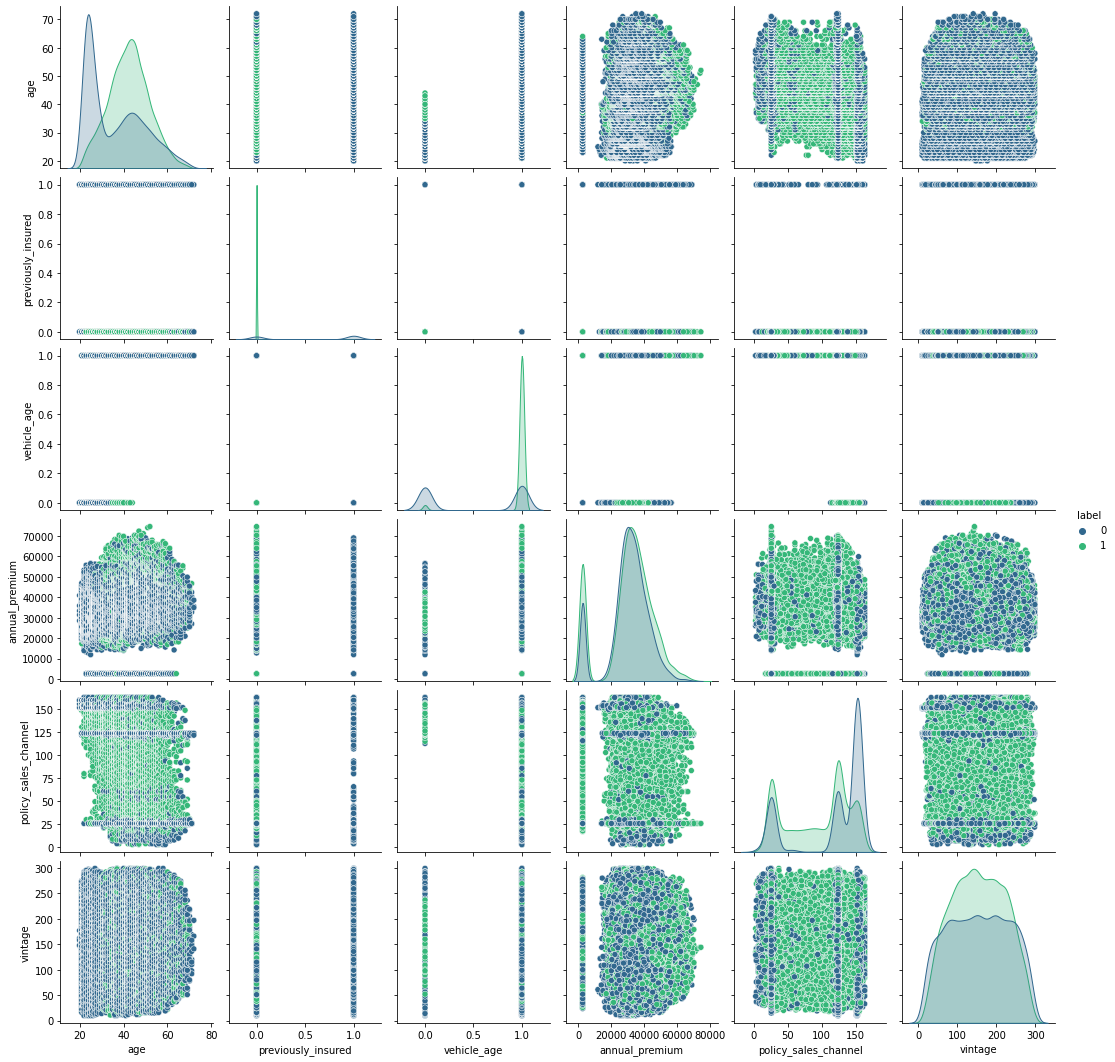

In [0]:
# Pair plot of the explanatory variables:

sns.pairplot(pd.concat([x_train, y_train], axis=1), hue="label", palette='viridis')

In [0]:
# Converting the data sets into pyspark format, and caching then to speed up the calculations. 

train_data = spark.createDataFrame(data=pd.concat([x_train, y_train], axis=1))
test_data = spark.createDataFrame(data=pd.concat([x_test, y_test], axis=1))
train_data.cache()
test_data.cache()

Out[57]: DataFrame[gender: string, age: smallint, previously_insured: smallint, vehicle_age: int, vehicle_damage: string, annual_premium: float, policy_sales_channel: float, vintage: smallint, label: smallint]

***

# Modelling:

## Data preparation:

In [0]:
featuresCols = train_data.columns 
featuresCols.remove("label")

In [0]:
indexOutputCols = [f + "_Index" for f in categoricalCols]
oheOutputCols = [f + "_OHE" for f in categoricalCols]

# Converting all catergorical features into indexes.
stringIndexer = StringIndexer(inputCols=categoricalCols, outputCols=indexOutputCols, handleInvalid="skip")
# Performing a one hot encoding on the categorical features.
oheEncoder = OneHotEncoder(inputCols=indexOutputCols, outputCols=oheOutputCols)
# Joining all numerical features into a single column.
assembler = VectorAssembler(inputCols=numericCols, outputCol= "numfeatures")
# Performing a min max scaler on the numercial features
scaler = MinMaxScaler(inputCol="numfeatures", outputCol="scaledFeatures") # StandardScaler

# Creating the 'features' column.
vectorAssembler = VectorAssembler(inputCols=oheOutputCols+["scaledFeatures"], outputCol="features")

In [0]:
# The stages list is an input for the 'Pipeline_model' function
stages = [stringIndexer, oheEncoder, assembler, scaler, vectorAssembler]

In [0]:
# The order of features.

features_names = ["Gender", "Previously_Insured", "Vehicle_Age", "Vehicle_Damage", "Age", "Annual_Premium", "Policy_Sales_Channel", "Vintage"]

***

## Logistic regression

In [0]:
lr = LogisticRegression(labelCol="label", probabilityCol='probability', fitIntercept=True)

In [0]:
evaluator=BinaryClassificationEvaluator(labelCol="label", rawPredictionCol='prediction', metricName='areaUnderROC')

- elasticNetParam=1, means Lasso.
- elasticNetParam=0, means Ridge.

- There are two parameters for this model, λ (regParam) and α (elasticNetParam), where α determines the type of regularization and λ gives the strength of regularization.

In [0]:
paramGrid=ParamGridBuilder().build()
# \
#                 .addGrid(lr.maxIter, (50, 100))\
#                 .addGrid(lr.tol, (1e-4, 1e-5))\
#                 .addGrid(lr.elasticNetParam, (0.0, 1.0))\
#                 .build()

# .addGrid(lr.regParam, (0.01, 0.001))\

In [0]:
# How many models?
print('Number of models to be tested: ', len(paramGrid))

Number of models to be tested:  1


In [0]:
# It is good to use a lasso regression as it will, gives some coefficients equal to 0. 

In [0]:
cv_lr = CrossValidator(estimator=lr,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [0]:
pipeline_model, predDF = Pipeline_model(stages, cv_lr, train_data, test_data)

In [0]:
cm = Metrics(predDF)

The confusion matrix of our model is as follow:

prediction   0.0   1.0
label                 
0           5039  1972
1            254  7852
The accuracy value is equal to 0.85
The precision value is equal to 0.80
The recall value is equal to 0.97
The F1-score value is equal to 0.87


In [0]:
y_test, y_pred_test_lr, y_pred_test_proba_lr = prediction_vectors(predDF)

              precision    recall  f1-score   support

           0       0.95      0.72      0.82      7011
           1       0.80      0.97      0.88      8106

    accuracy                           0.85     15117
   macro avg       0.88      0.84      0.85     15117
weighted avg       0.87      0.85      0.85     15117



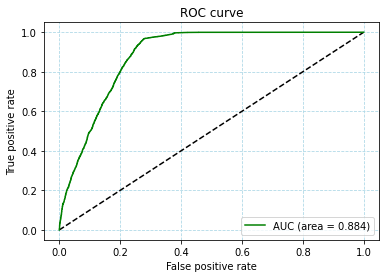

In [0]:
auc_plot(y_test, y_pred_test_proba_lr)

In [0]:
cv_model = pipeline_model.stages[-1]
lr_summary = cv_model.bestModel.summary

In [0]:
# Better way the show the hyperparameters:

print(cv_model.bestModel.getRegParam())
print(cv_model.bestModel.getMaxIter())
print(cv_model.bestModel.getTol())
print(cv_model.bestModel.getElasticNetParam())

0.0
100
1e-06
0.0


In [0]:
cv_model.bestModel.getParam("regParam")

Out[74]: Param(parent='LogisticRegression_e3b58adde743', name='regParam', doc='regularization parameter (>= 0).')

In [0]:
features_imp = pd.DataFrame(list(zip(featuresCols, cv_model.bestModel.coefficients)),
                             columns=["feature", "Coefficient"])

features_imp.sort_values(by=["Coefficient"], ascending=False)

,feature,Coefficient
1,age,4.905918
2,previously_insured,4.017465
3,vehicle_age,3.019467
5,annual_premium,0.423276
0,gender,0.320930
6,policy_sales_channel,-0.098305
7,vintage,-0.152816
4,vehicle_damage,-2.173949


In [0]:
# Number of zero coefficients:

zero_coeff = sum([beta==0 for beta in cv_model.bestModel.coefficients])
print("The number of coefficients equal to 0 is:", zero_coeff)

The number of coefficients equal to 0 is: 0


***

## Neural Network

In [0]:
nn = MultilayerPerceptronClassifier(featuresCol="features", labelCol="label", seed=SEED)

In [0]:
paramGrid=ParamGridBuilder().addGrid(nn.maxIter, [50, 100]).addGrid(nn.layers, [[8, 5, 2], [8, 20, 2]]).build()

In [0]:
# How many models?
print('Number of models to be tested: ', len(paramGrid))


Number of models to be tested:  4


In [0]:
cv_nn = CrossValidator(estimator=nn,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [0]:
# Takes 9.31 min

pipeline_model, predDF = Pipeline_model(stages, cv_nn, train_data, test_data)

In [0]:
cm = Metrics(predDF)

The confusion matrix of our model is as follow:

prediction   0.0   1.0
label                 
0           5138  1873
1            391  7715
The accuracy value is equal to 0.85
The precision value is equal to 0.80
The recall value is equal to 0.95
The F1-score value is equal to 0.87


In [0]:
y_test_nn, y_pred_test_nn, y_pred_test_proba_nn = prediction_vectors(predDF)

              precision    recall  f1-score   support

           0       0.93      0.73      0.82      7011
           1       0.80      0.95      0.87      8106

    accuracy                           0.85     15117
   macro avg       0.87      0.84      0.85     15117
weighted avg       0.86      0.85      0.85     15117



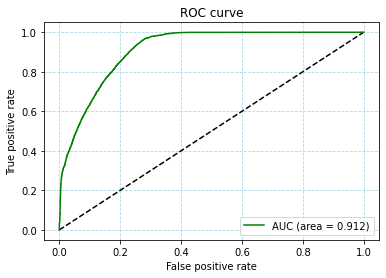

In [0]:
auc_plot(y_test_nn, y_pred_test_proba_nn)

In [0]:
cv_model = pipeline_model.stages[-1]
cv_model.bestModel

Out[85]: MultilayerPerceptronClassificationModel: uid=MultilayerPerceptronClassifier_5641274afd55, numLayers=3, numClasses=2, numFeatures=8

In [0]:
# Better way the show the hyperparameters:

print(cv_model.bestModel.getMaxIter())
print(cv_model.bestModel.getLayers())

100
[8, 20, 2]


***

## Decision Tree

In [0]:
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", seed=SEED)

In [0]:
evaluator=BinaryClassificationEvaluator(labelCol="label", rawPredictionCol='prediction', metricName='areaUnderROC')

In [0]:
paramGrid=ParamGridBuilder().build()

In [0]:
# How many models?
print('Number of models to be tested: ', len(paramGrid))

Number of models to be tested:  1


In [0]:
cv_dt = CrossValidator(estimator=dt,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [0]:
#  sec with only one model.

pipeline_model, predDF = Pipeline_model(stages, cv_dt, train_data, test_data)

In [0]:
cm = Metrics(predDF)

The confusion matrix of our model is as follow:

prediction   0.0   1.0
label                 
0           4997  2014
1            150  7956
The accuracy value is equal to 0.86
The precision value is equal to 0.80
The recall value is equal to 0.98
The F1-score value is equal to 0.88


In [0]:
y_test_dt, y_pred_test_dt, y_pred_test_proba_dt = prediction_vectors(predDF)

              precision    recall  f1-score   support

           0       0.97      0.71      0.82      7011
           1       0.80      0.98      0.88      8106

    accuracy                           0.86     15117
   macro avg       0.88      0.85      0.85     15117
weighted avg       0.88      0.86      0.85     15117



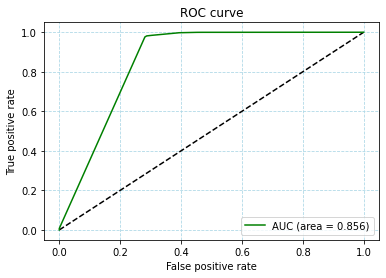

In [0]:
auc_plot(y_test_dt, y_pred_test_proba_dt)

In [0]:
cv_model = pipeline_model.stages[-1]
# dt_summary = cv_model.bestModel.summary
#  dt_summary

In [0]:
# Better way the show the hyperparameters:

print(cv_model.bestModel.getMaxDepth())

5


In [0]:
features_imp = pd.DataFrame(list(zip(features_names, cv_model.bestModel.featureImportances)),
                             columns=["feature", "importance"])

features_imp.sort_values(by="importance", ascending=False)

,feature,importance
2,Vehicle_Age,0.813635
3,Vehicle_Damage,0.120552
1,Previously_Insured,0.036657
6,Policy_Sales_Channel,0.027357
4,Age,0.001798
5,Annual_Premium,0.000002
0,Gender,0.000000
7,Vintage,0.000000


***

## Random forest

In [0]:
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=SEED)

In [0]:
evaluator=BinaryClassificationEvaluator(labelCol="label", rawPredictionCol='prediction', metricName='areaUnderROC')

In [0]:
paramGrid=ParamGridBuilder().build()
# \
#                 .addGrid(rf.maxDepth, [5, 10, 20]) \
#                 .addGrid(rf.numTrees, [20, 40, 60 ]) \
#                 .build()

#                 .addGrid(rf.maxBins, [20, 32, 50]) \
#                 .addGrid(rf.minInfoGain, [0., 0.01, 0.1]) \
#                 .addGrid(rf.impurity, ["gini", "entropy"]) \
#                 .addGrid(rf.minInstancesPerNode, [1, 5, 10]) \    

In [0]:
# How many models?
print('Number of models to be tested: ', len(paramGrid))

Number of models to be tested:  1


In [0]:
cv_rf = CrossValidator(estimator=rf,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [0]:
# 44.70 sec with only one model.

pipeline_model, predDF = Pipeline_model(stages, cv_rf, train_data, test_data)

In [0]:
cm = Metrics(predDF)

The confusion matrix of our model is as follow:

prediction   0.0   1.0
label                 
0           5011  2000
1            164  7942
The accuracy value is equal to 0.86
The precision value is equal to 0.80
The recall value is equal to 0.98
The F1-score value is equal to 0.88


In [0]:
y_test_rf, y_pred_test_rf, y_pred_test_proba_rf = prediction_vectors(predDF)

              precision    recall  f1-score   support

           0       0.97      0.71      0.82      7011
           1       0.80      0.98      0.88      8106

    accuracy                           0.86     15117
   macro avg       0.88      0.85      0.85     15117
weighted avg       0.88      0.86      0.85     15117



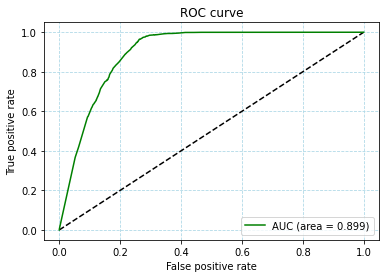

In [0]:
auc_plot(y_test_rf, y_pred_test_proba_rf)

In [0]:
cv_model = pipeline_model.stages[-1]
rf_summary = cv_model.bestModel.summary
rf_summary

Out[108]: <pyspark.ml.classification.BinaryRandomForestClassificationTrainingSummary at 0x7f3c780a4700>

In [0]:
# Better way the show the hyperparameters:

print(cv_model.bestModel.getMaxDepth())
print(cv_model.bestModel.getNumTrees)

5
20


In [0]:
features_imp = pd.DataFrame(list(zip(features_names, cv_model.bestModel.featureImportances)),
                             columns=["feature", "importance"])

features_imp.sort_values(by="importance", ascending=False)

,feature,importance
2,Vehicle_Age,0.363636
1,Previously_Insured,0.308167
3,Vehicle_Damage,0.164163
6,Policy_Sales_Channel,0.137261
4,Age,0.023088
0,Gender,0.001492
7,Vintage,0.001201
5,Annual_Premium,0.000991


In [0]:
list(zip(cv_model.getEstimatorParamMaps(), cv_model.avgMetrics))

Out[111]: [({}, 0.8489400711897036)]

***

## Gradient Boosting:

In [0]:
gb = GBTClassifier(featuresCol="features", labelCol="label", seed=SEED)

In [0]:
# I should definetly fine tune this model or i will get super shit results.
paramGrid=ParamGridBuilder().build()
# .addGrid(gb.maxDepth, [5, 8]).addGrid(gb.minInstancesPerNode, [2, 5])

## this takes too much time, i need to tweak it to get better results.
#.addGrid(gb.maxBins, [20, 32, 50]) \
                #.addGrid(gb.maxIter, [10, 20, 30]) \

In [0]:
# How many models?
print('Number of models to be tested: ', len(paramGrid))

Number of models to be tested:  1


In [0]:
# The other way arround is better I guess:

cv_gb = CrossValidator(estimator=gb,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=2,
                        seed=SEED)

In [0]:
# 5.72 min with only 1 model.

pipeline_model, predDF = Pipeline_model(stages, cv_gb, train_data, test_data)

In [0]:
cm = Metrics(predDF)

The confusion matrix of our model is as follow:

prediction   0.0   1.0
label                 
0           5206  1805
1            281  7825
The accuracy value is equal to 0.86
The precision value is equal to 0.81
The recall value is equal to 0.97
The F1-score value is equal to 0.88


In [0]:
y_test_gb, y_pred_test_gb, y_pred_test_proba_gb = prediction_vectors(predDF)

              precision    recall  f1-score   support

           0       0.95      0.74      0.83      7011
           1       0.81      0.97      0.88      8106

    accuracy                           0.86     15117
   macro avg       0.88      0.85      0.86     15117
weighted avg       0.88      0.86      0.86     15117



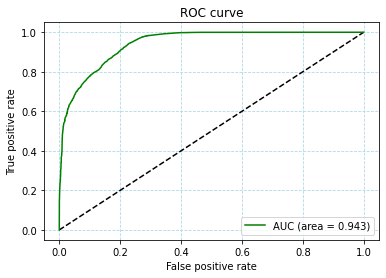

In [0]:
auc_plot(y_test_gb, y_pred_test_proba_gb)

In [0]:
cv_model = pipeline_model.stages[-1]
cv_model.bestModel

Out[120]: GBTClassificationModel: uid = GBTClassifier_96f301d48a6f, numTrees=20, numClasses=2, numFeatures=8

In [0]:
# cv_model.bestModel.extractParamMap()

In [0]:
# Better way the show the hyperparameters:

print(cv_model.bestModel.getMaxDepth())
print(cv_model.bestModel.getMinInstancesPerNode())

5
1


In [0]:
features_imp = pd.DataFrame(list(zip(features_names, cv_model.bestModel.featureImportances)),
                             columns=["feature", "importance"])

features_imp.sort_values(by="importance", ascending=False)

,feature,importance
2,Vehicle_Age,0.402233
6,Policy_Sales_Channel,0.366704
1,Previously_Insured,0.078832
4,Age,0.056907
3,Vehicle_Damage,0.037954
7,Vintage,0.025617
5,Annual_Premium,0.023552
0,Gender,0.008201


***

## Statistical tests

In [0]:
!pip install mlxtend

     |████████████████████████████████| 1.3 MB 6.5 MB/s 
     |██▏                             | 2.1 MB 38.6 MB/s eta 0:

*** WARNING: max output size exceeded, skipping output. ***

     |████████████████████████████████| 31.2 MB 134 kB/s 
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.24.1
    Uninstalling scikit-learn-0.24.1:
      Successfully uninstalled scikit-learn-0.24.1
You should consider upgrading via the '/databricks/python3/bin/python -m pip install --upgrade pip' command.


- The null hypothesis there is no difference between the classification accuracies \\( p_{i} \\). 
$$ H_{0}:p_{1}=p_{2}=...=p_{L} $$
- The alternative hypothesis is there is a difference between the classification accuracies.

In [0]:
from mlxtend.evaluate import ftest

f, p_value = ftest(y_test, 
                    y_pred_test_lr, 
                    y_pred_test_nn, 
                    y_pred_test_dt,
                    y_pred_test_rf,
                    y_pred_test_gb)

print('F: %.3f' % f)
print('p-value: %.3f' % p_value)

F: 31.384
p-value: 0.000


We conclude that there is a difference between the classifiers.

Reference: http://rasbt.github.io/mlxtend/user_guide/evaluate/mcnemar/

- The null hypothesis: None of the two models performs better than the other.
- The alternative hypothesis is that the performances of the two models are not equal.

In [0]:
from mlxtend.evaluate import mcnemar_table, mcnemar

tb = mcnemar_table(y_target=y_test, 
                   y_model1=y_pred_test_rf, 
                   y_model2=y_pred_test_gb)

print(pd.DataFrame(tb))

chi2, p = mcnemar(ary=tb, corrected=True)

print('chi-squared:', chi2)
print('p-value:', p)

       0     1
0  12819   134
1    212  1952
chi-squared: 17.13583815028902
p-value: 3.479943574780522e-05


We conclude that the performances of the two models are not equal, the Gradient Boosting model performs better in this case.

# Batch Processing from Kafka
Under clusters -> libraries -> maven -> search packages, install spark-kafka-writer. The coordinates is com.github.benfradet:spark-kafka-writer_2.11:0.4.0

In [0]:
KAFKA_TEST_DATA = 100

x_test_kafka = x_test.iloc[0:KAFKA_TEST_DATA].copy(deep=True)
x_test_kafka['value'] = x_test_kafka.apply(lambda x: x.to_json(), axis=1)
y_test_kafka = test_data.toPandas()['label'].iloc[0:KAFKA_TEST_DATA]
test_data_kafka = spark.createDataFrame(data=x_test_kafka)
# Write test data to kafka
test_data_kafka.write \
  .format("kafka") \
  .option("kafka.bootstrap.servers", KAFKA_HOST_PORT) \
  .option("topic", KAFKA_TOPIC) \
  .option("kafka.sasl.jaas.config", "org.apache.kafka.common.security.scram.ScramLoginModule required username=\"aHVtYmxlLWNhdC0xNDQzNiQPm_F1rwy3b1Kj__OZ6lQ0g4CxxtQygbcrBh6XEOc\" password=\"weDC7M2nN0Nu_NavHHkhkLk3HFJWKwCxkBghYcdBsWkk8D-NkXQAQM4g10m8749kfDTHFw==\";") \
  .option("kafka.security.protocol", "SASL_SSL") \
  .option("kafka.sasl.mechanism", "SCRAM-SHA-256") \
  .save()

In [0]:
# Read test data from kafka
test_data_from_kafka = spark.read \
  .format("kafka") \
  .option("kafka.bootstrap.servers", KAFKA_HOST_PORT) \
  .option("subscribe", KAFKA_TOPIC) \
  .option("kafka.sasl.jaas.config", "org.apache.kafka.common.security.scram.ScramLoginModule required username=\"aHVtYmxlLWNhdC0xNDQzNiQPm_F1rwy3b1Kj__OZ6lQ0g4CxxtQygbcrBh6XEOc\" password=\"weDC7M2nN0Nu_NavHHkhkLk3HFJWKwCxkBghYcdBsWkk8D-NkXQAQM4g10m8749kfDTHFw==\";") \
  .option("kafka.security.protocol", "SASL_SSL") \
  .option("kafka.sasl.mechanism", "SCRAM-SHA-256") \
  .option("includeHeaders", "true") \
  .option("startingOffsets", "earliest") \
  .load()
test_data_from_kafka.printSchema()
# Predict test data from kafka
data_from_kafka = []
for row in test_data_from_kafka.toPandas()['value']:
    data_from_kafka.append(json.loads(row))
data_from_kafka = pd.DataFrame(data_from_kafka)
kafka_pred_df = pipeline_model.transform(spark.createDataFrame(data=pd.concat([data_from_kafka, y_test_kafka], axis=1)))
Metrics(kafka_pred_df)

root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)
 |-- headers: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- key: string (nullable = true)
 |    |    |-- value: binary (nullable = true)

The confusion matrix of our model is as follow:

prediction  0.0  1.0
label               
0.0          90    0
1.0           9    1
The accuracy value is equal to 0.91
The precision value is equal to 0.99
The recall value is equal to 0.10
The F1-score value is equal to 0.18


prediction,0.0,1.0
label,,
0.0,90,0
1.0,9,1


# Streaming
We explore streaming logistic regression with SGD using text file stream. This algorithm watches for new files in the training and testing directory. All compuation has to be predefined before starting the streaming context. 
When we are done, we have to stop the streaming context without stopping the spark context.

In [0]:
# https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.streaming.StreamingContext.textFileStream.html#pyspark.streaming.StreamingContext.textFileStream file must be UTF-8 encoded
train_data.write.mode("overwrite").format("csv").option("encoding", "UTF-8").save('/insurance/train')
test_data.write.mode("overwrite").format("csv").option("encoding", "UTF-8").save('/insurance/test')
streaming_lr = StreamingLogisticRegressionWithSGD(stepSize=0.01, regParam=0.001)
streaming_lr.setInitialWeights([0.01 for _ in range(0, len(x_train.columns))])

Out[136]: <pyspark.mllib.classification.StreamingLogisticRegressionWithSGD at 0x7f3c7072f1c0>

In [0]:
def find_csv(dir):
    return [file.path for file in dbutils.fs.ls(dir) if os.path.basename(file.path).endswith('.csv')][0]

def parseText(row):
    if row:
        # Each line is a row, the order is
        # gender,age,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,label
        # gender is a string Female/Male, we will convert it to 0/1
        # vehicle_damage is a bool Yes/No, we will convert it to 0/1
        features = row.split(',')
        features[0] = 0 if features[0] == 'Female' else 1
        features[4] = 0 if features[4] == 'Yes' else 1
        feat_vec = Vectors.dense([float(f) for f in features[0:-1]])
        label = int(features[-1])
        return LabeledPoint(label, feat_vec)

In [0]:
train_file = find_csv('dbfs:/insurance/train/')
test_file = find_csv('dbfs:/insurance/test/')

In [0]:
ssc = StreamingContext(sc, 5)
train_data_stream = ssc.textFileStream('dbfs:/insurance/train/data').map(parseText).cache()
test_data_stream = ssc.textFileStream('dbfs:/insurance/test/data').map(parseText)
# Copy the file to the train stream and test stream directories because the streams only read from new files
dbutils.fs.cp(train_file, 'dbfs:/insurance/train/data/train.csv')
dbutils.fs.cp(test_file, 'dbfs:/insurance/test/data/test.csv')
train_data_stream.pprint(10)
test_data_stream.pprint(10)
streaming_lr.trainOn(train_data_stream)
stream_pred = streaming_lr.predictOnValues(test_data_stream.map(lambda lp: (lp.label, lp.features)))
stream_pred.pprint(100)
ssc.start()
try:
    ssc.awaitTermination(60)
finally:
    ssc.stop(stopSparkContext=False)

-------------------------------------------
Time: 2022-07-02 22:15:40
-------------------------------------------
(0.0,[0.0,20.0,0.0,0.0,0.0,40959.0,152.0,162.0])
(0.0,[0.0,20.0,1.0,0.0,1.0,33355.0,160.0,158.0])
(0.0,[0.0,21.0,0.0,0.0,1.0,22395.0,152.0,175.0])
(0.0,[0.0,21.0,0.0,0.0,1.0,23226.0,152.0,147.0])
(0.0,[0.0,21.0,0.0,0.0,1.0,23622.0,152.0,141.0])
(0.0,[0.0,21.0,0.0,0.0,1.0,25142.0,152.0,191.0])
(0.0,[0.0,21.0,0.0,0.0,1.0,26929.0,160.0,156.0])
(0.0,[0.0,21.0,0.0,0.0,1.0,28668.0,152.0,249.0])
(0.0,[0.0,21.0,0.0,0.0,1.0,29681.0,160.0,119.0])
(1.0,[0.0,21.0,0.0,0.0,1.0,30953.0,152.0,72.0])
...

-------------------------------------------
Time: 2022-07-02 22:15:40
-------------------------------------------
(0.0,[0.0,20.0,1.0,0.0,1.0,30906.0,160.0,153.0])
(0.0,[0.0,21.0,0.0,0.0,1.0,21236.0,152.0,51.0])
(1.0,[0.0,21.0,0.0,0.0,1.0,22377.0,152.0,210.0])
(0.0,[0.0,21.0,0.0,0.0,1.0,24747.0,152.0,105.0])
(0.0,[0.0,21.0,0.0,0.0,1.0,28767.0,152.0,203.0])
(0.0,[0.0,21.0,0.0,0.0,1.0,29610.0

In [0]:
t2 = time.perf_counter()
print('Time taken to run in minutes:',(t2-t1)/60.0)

Time taken to run in minutes: 38.515838786616705
